In [49]:
import os
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely

from pygam import LogisticGAM, s, f
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score,
    balanced_accuracy_score, average_precision_score
)

# ============================================================
# 0) PARAMETROS
# ============================================================
path_gpkg = "/home/oisanchezp/Thesis/data/metadata/slope_units_con_inventario.gpkg"
layer_in  = "slope_units_full"

pluv_meta   = "/home/oisanchezp/Thesis/data/metadata/pluviometros_metadatos_20250506.csv"
ruta_series = "/mnt/investigacion/geotecnia/Pluvios_horarios/Pluvios_horarios_completos/"

MIN_DIST_M = 500
T_DAYS = 1
P_DAYS = 33
TOTAL_DAYS = T_DAYS + P_DAYS

H1 = 24

# ============================================================
# 1) UTILIDADES: pluvios + lluvia
# ============================================================

def read_pluvios_as_gdf(pluv_meta_csv, target_crs):
    pl = pd.read_csv(pluv_meta_csv)
    pl["FechaInstalacion"] = pd.to_datetime(pl["FechaInstalacion"], errors="coerce")

    gpl = gpd.GeoDataFrame(
        pl,
        geometry=gpd.points_from_xy(pl["Longitude"], pl["Latitude"]),
        crs="EPSG:4326"
    ).to_crs(target_crs)

    return gpl[["Codigo", "FechaInstalacion", "geometry"]].copy()


def assign_nearest_valid_gauge(su_gdf, gpl, min_days, date_col="fecha_hora_evento"):
    """
    Para cada SU asigna el pluviómetro más cercano que cumpla:
    fecha_evento >= FechaInstalacion + min_days
    """
    su_gdf = su_gdf.copy()
    su_gdf[date_col] = pd.to_datetime(su_gdf[date_col], errors="coerce")

    gauges_geom = gpl.geometry.values
    gauges_code = gpl["Codigo"].to_numpy()
    gauges_inst = pd.to_datetime(gpl["FechaInstalacion"]).to_numpy(dtype="datetime64[ns]")

    codes_out = np.full(len(su_gdf), np.nan)
    dist_out  = np.full(len(su_gdf), np.nan)

    delta = np.timedelta64(int(min_days), "D")

    for i, (geom, t_event) in enumerate(zip(
        su_gdf.geometry.values,
        su_gdf[date_col].to_numpy(dtype="datetime64[ns]")
    )):
        if geom is None or pd.isna(t_event):
            continue

        valid = t_event >= (gauges_inst + delta)
        if not np.any(valid):
            continue

        d = shapely.distance(geom, gauges_geom)  # Shapely 2 (vectorizado)
        d = np.where(valid, d, np.inf)

        j = int(np.argmin(d))
        if np.isinf(d[j]):
            continue

        codes_out[i] = gauges_code[j]
        dist_out[i]  = float(d[j])

    su_gdf["Codigo_pluvio"] = codes_out
    su_gdf["dist_pluv_m"]   = dist_out
    return su_gdf


def load_hourly_cumsum_for_gauge(cod, ruta_series):
    fn = f"H_Datos_Procesados_Est_{cod}.csv"
    path = os.path.join(ruta_series, fn)
    if not os.path.exists(path):
        return None

    df = pd.read_csv(path, usecols=["Fecha", "P"], parse_dates=["Fecha"])
    serie_h = (df.groupby("Fecha")["P"].sum()
                 .sort_index()
                 .asfreq("H", fill_value=0.0))

    cs = serie_h.cumsum().astype(np.float32)
    return cs


def compute_Rk_at_time(cs, tstamp, k_days):
    """R_k (acumulado en k días) a partir de cumsum horario."""
    if cs is None or cs.empty:
        return np.nan

    t = pd.Timestamp(tstamp).floor("H")

    # encontrar índice (pad hacia atrás si no coincide exacto)
    try:
        pos = cs.index.get_loc(t)
    except KeyError:
        loc = cs.index.get_indexer([t], method="pad")
        pos = int(loc[0])
        if pos < 0:
            return np.nan

    lag = k_days * H1
    if pos - lag < 0:
        return np.nan

    return float(cs.iloc[pos] - cs.iloc[pos - lag])


def add_rain_columns(df, gauge_col, date_col, ruta_series, k_list):
    """
    Agrega columnas tipo '1d', '34d' calculadas con el pluviómetro más cercano.
    Cachea la serie por pluviómetro para no releer mil veces.
    """
    df = df.copy()
    cache = {}

    for k in k_list:
        df[f"{k}d"] = np.nan

    for cod, idxs in df.groupby(gauge_col).groups.items():
        cod = int(cod) if pd.notna(cod) else cod
        if pd.isna(cod):
            continue

        if cod not in cache:
            cache[cod] = load_hourly_cumsum_for_gauge(cod, ruta_series)

        cs = cache[cod]
        for i in idxs:
            tstamp = df.at[i, date_col]
            for k in k_list:
                df.at[i, f"{k}d"] = compute_Rk_at_time(cs, tstamp, k)

    return df


# ============================================================
# 2) CONSTRUCTOR MC (Paquete B): diferente lugar, misma fecha
# ============================================================

def construir_si_no_spatial_mc(seed,
                               path_gpkg, layer_in,
                               pluv_meta_csv, ruta_series,
                               min_dist_m=500):
    rng = np.random.default_rng(seed)

    su = gpd.read_file(path_gpkg, layer=layer_in)
    su["fecha_hora_evento"] = pd.to_datetime(su["fecha_hora_evento"], errors="coerce")

    if su.crs is None:
        raise ValueError("Tu layer no tiene CRS. Asigna CRS antes de medir 500m.")
    if su.crs.is_geographic:
        su = su.to_crs("EPSG:3116")  # MAGNA-SIRGAS / Colombia Bogota zone

    su_si = su[su["si_no"] == 1].copy()
    su_no = su[su["si_no"] == 0].copy()

    if len(su_si) == 0:
        raise ValueError("No hay filas con si_no==1 en la capa.")

    # pool NO elegibles: distancia > min_dist_m a cualquier SI
    buffer_union = su_si.geometry.buffer(min_dist_m).unary_union
    su_no_eligible = su_no[~su_no.geometry.intersects(buffer_union)].copy()

    n_si = len(su_si)
    n_no_target = 2 * n_si

    if len(su_no_eligible) < n_no_target:
        raise ValueError(
            f"No hay suficientes NO elegibles a >{min_dist_m}m. "
            f"Necesitas {n_no_target}, hay {len(su_no_eligible)}."
        )

    sampled_idx = rng.choice(su_no_eligible.index.values, size=n_no_target, replace=False)
    df_no = su_no_eligible.loc[sampled_idx].copy()

    # asignar fechas/dinámicas: duplico SI para llegar a 2*n_si
    si_dyn = su_si[["fecha_hora_evento", "Mes", "ONI", "ENSO"]].copy().reset_index(drop=True)
    si_dyn2 = pd.concat([si_dyn, si_dyn], ignore_index=True)

    si_dyn2 = si_dyn2.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    df_no   = df_no.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    df_no["fecha_hora_evento"] = si_dyn2["fecha_hora_evento"].values
    df_no["Mes"]  = si_dyn2["Mes"].values
    df_no["ONI"]  = si_dyn2["ONI"].values
    df_no["ENSO"] = si_dyn2["ENSO"].values

    # por consistencia: recalcular Mes y DoY desde fecha
    su_si["Mes"] = su_si["fecha_hora_evento"].dt.month
    su_si["DoY"] = su_si["fecha_hora_evento"].dt.dayofyear
    df_no["Mes"] = pd.to_datetime(df_no["fecha_hora_evento"]).dt.month
    df_no["DoY"] = pd.to_datetime(df_no["fecha_hora_evento"]).dt.dayofyear

    # pluviómetro más cercano válido para SI y NO
    gpl = read_pluvios_as_gdf(pluv_meta_csv, target_crs=su_si.crs)

    su_si = assign_nearest_valid_gauge(su_si, gpl, min_days=TOTAL_DAYS, date_col="fecha_hora_evento")
    df_no = assign_nearest_valid_gauge(df_no, gpl, min_days=TOTAL_DAYS, date_col="fecha_hora_evento")

    su_si = su_si.dropna(subset=["Codigo_pluvio"]).copy()
    df_no = df_no.dropna(subset=["Codigo_pluvio"]).copy()
    su_si["Codigo_pluvio"] = su_si["Codigo_pluvio"].astype(int)
    df_no["Codigo_pluvio"] = df_no["Codigo_pluvio"].astype(int)

    # lluvia: necesitamos R_1d y R_(T+P)=R_34d
    k_list = [T_DAYS, TOTAL_DAYS]
    su_si = add_rain_columns(su_si, "Codigo_pluvio", "fecha_hora_evento", ruta_series, k_list)
    df_no = add_rain_columns(df_no, "Codigo_pluvio", "fecha_hora_evento", ruta_series, k_list)

    # ENSO_code y cíclicas (no se usan en este modelo actual, pero quedan disponibles)
    enso_map = {"La Niña": 0, "Neutro": 1, "El Niño": 2}
    for dff in [su_si, df_no]:
        dff["ENSO_code"] = dff["ENSO"].map(enso_map).astype("Int64")
        dff["doy_rad"] = 2 * np.pi * (dff["DoY"] - 1) / 365.0
        dff["sin_doy"] = np.sin(dff["doy_rad"])
        dff["cos_doy"] = np.cos(dff["doy_rad"])

    df_combined = pd.concat([su_si, df_no], ignore_index=True)

    needed = ["fecha_hora_evento", "si_no", "Codigo_pluvio", "1d", f"{TOTAL_DAYS}d"]
    df_combined = df_combined.dropna(subset=needed).copy()
    df_combined["si_no"] = df_combined["si_no"].astype(int)

    print(f"[MC seed={seed}] SI={len(su_si)} | NO_elegibles={len(su_no_eligible)} | NO_sample={len(df_no)} | total_final={len(df_combined)}")
    return df_combined


# ============================================================
# 3) Dataset (T,P + estáticas) para modelos
# ============================================================

def build_TP_dataset_newvars(
    df,
    t_days=1,
    p_days=33,
    col_geo="geologia",
    col_cov="cobertura",
    col_slope="slope_mean",
    col_area="area"
):
    total_days = t_days + p_days
    col_T = f"{t_days}d"
    col_tot = f"{total_days}d"

    needed = [col_T, col_tot, col_geo, col_cov, col_slope, col_area, "si_no"]
    sub = df.dropna(subset=needed).copy()
    if sub.empty or sub["si_no"].nunique() < 2:
        raise ValueError("No hay datos suficientes o falta una clase.")

    # T y P
    T_vals = sub[col_T].to_numpy(dtype=float)
    P_vals = sub[col_tot].to_numpy(dtype=float) - sub[col_T].to_numpy(dtype=float)

    slope = sub[col_slope].to_numpy(dtype=float)
    area  = sub[col_area].to_numpy(dtype=float)
    log_area = np.log1p(area)

    geo_cat = pd.Categorical(sub[col_geo])
    geo_code = geo_cat.codes

    cov_cat = pd.Categorical(sub[col_cov].astype(str))
    cov_code = cov_cat.codes

    geo_code_to_name = dict(enumerate(geo_cat.categories.astype(str)))
    cov_code_to_name = dict(enumerate(cov_cat.categories.astype(str)))

    # Vista GAM (numérica)
    X_gam = np.column_stack([T_vals, P_vals, slope, log_area, geo_code, cov_code]).astype(float)

    # Vista sklearn (mixta)
    X_df_ml = pd.DataFrame({
        "T": T_vals,
        "P": P_vals,
        "slope_mean": slope,
        "log_area": log_area,
        "geologia": geo_cat.astype(str),
        "cobertura": cov_cat.astype(str),
    }, index=sub.index)

    y = sub["si_no"].to_numpy(dtype=int)
    return X_gam, X_df_ml, y, geo_code_to_name, cov_code_to_name


# ============================================================
# 4) Importancia por permutación (AUC drop) + modelos
# ============================================================

FEATURE_NAMES_B = ["T", "P", "slope_mean", "log_area", "geologia", "cobertura"]

def _proba1(model, X):
    p = model.predict_proba(X)
    p = np.asarray(p)
    if p.ndim == 2:
        return p[:, 1]
    return p

def permutation_importance_auc_drop_array(model, X_test_arr, y_test, feature_names, n_perm=100, seed=0):
    """
    Para X_test tipo np.ndarray (GAM).
    Retorna mean drop, CI y todas las permutaciones.
    """
    rng = np.random.default_rng(seed)

    y_prob_base = _proba1(model, X_test_arr)
    auc_base = roc_auc_score(y_test, y_prob_base)

    drops_all = {}
    for j, name in enumerate(feature_names):
        drops = np.zeros(n_perm, dtype=float)
        for k in range(n_perm):
            Xp = X_test_arr.copy()
            Xp[:, j] = rng.permutation(Xp[:, j])
            y_prob_p = _proba1(model, Xp)
            auc_p = roc_auc_score(y_test, y_prob_p)
            drops[k] = auc_base - auc_p
        drops_all[name] = drops

    drops_mean = {v: float(np.mean(arr)) for v, arr in drops_all.items()}
    drops_ci   = {v: (float(np.quantile(arr, 0.025)), float(np.quantile(arr, 0.975))) for v, arr in drops_all.items()}
    return drops_mean, drops_ci, drops_all


def permutation_importance_auc_drop_df(model, X_test_df, y_test, feature_names, n_perm=100, seed=0):
    """
    Para X_test tipo DataFrame (Logit con pipeline y RF con pipeline).
    Permuta columnas crudas y mide caída de AUROC en X_test (sin leakage).
    """
    rng = np.random.default_rng(seed)

    y_prob_base = _proba1(model, X_test_df)
    auc_base = roc_auc_score(y_test, y_prob_base)

    drops_all = {}
    for name in feature_names:
        drops = np.zeros(n_perm, dtype=float)
        for k in range(n_perm):
            Xp = X_test_df.copy()
            Xp[name] = rng.permutation(Xp[name].to_numpy())
            y_prob_p = _proba1(model, Xp)
            auc_p = roc_auc_score(y_test, y_prob_p)
            drops[k] = auc_base - auc_p
        drops_all[name] = drops

    drops_mean = {v: float(np.mean(arr)) for v, arr in drops_all.items()}
    drops_ci   = {v: (float(np.quantile(arr, 0.025)), float(np.quantile(arr, 0.975))) for v, arr in drops_all.items()}
    return drops_mean, drops_ci, drops_all


# ---------- GAM ----------
terms = (
    s(0, n_splines=6) +   # T
    s(1, n_splines=6) +   # P
    s(2, n_splines=6) +   # slope_mean
    s(3, n_splines=6) +   # log_area
    f(4) +                # geologia (factor)
    f(5)                  # cobertura (factor)
)

lam_grid = np.logspace(0, 3, 5)

def get_best_lambda_train_only(X_train, y_train, random_state=42):
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.3, stratify=y_train, random_state=random_state
    )
    best_lam = lam_grid[0]
    best_auc = -np.inf
    for lam in lam_grid:
        gam = LogisticGAM(terms, lam=lam).fit(X_tr, y_tr)
        auc = roc_auc_score(y_val, gam.predict_proba(X_val))
        if auc > best_auc:
            best_auc = auc
            best_lam = lam
    return best_lam


def evaluate_models_once(
    df_mc,
    t_days=1,
    p_days=33,
    test_size=0.30,
    random_state=42,
    thr=0.5,
    col_geo="geologia",
    col_cov="cobertura",
    col_slope="slope_mean",
    col_area="area",
    n_perm=100,
    seed_perm=123
):
    X_gam, X_df_ml, y, geo_map, cov_map = build_TP_dataset_newvars(
        df_mc, t_days=t_days, p_days=p_days,
        col_geo=col_geo, col_cov=col_cov, col_slope=col_slope, col_area=col_area
    )

    idx = np.arange(len(y))
    idx_train, idx_test = train_test_split(
        idx, test_size=test_size, stratify=y, random_state=random_state
    )

    Xg_tr, Xg_te = X_gam[idx_train], X_gam[idx_test]
    Xm_tr, Xm_te = X_df_ml.iloc[idx_train].copy(), X_df_ml.iloc[idx_test].copy()
    y_tr, y_te   = y[idx_train], y[idx_test]

    def eval_once(y_true, y_prob, thr=0.5):
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        pofd = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        hk = (recall - pofd) if ((tp + fn) > 0 and (fp + tn) > 0) else 0.0

        return {
            "auc":  float(roc_auc_score(y_true, y_prob)),
            "ap":   float(average_precision_score(y_true, y_prob)),
            "f1":   float(f1_score(y_true, y_pred, zero_division=0)),
            "bacc": float(balanced_accuracy_score(y_true, y_pred)),
            "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
            "recall": float(recall),
            "precision": float(precision),
            "pofd": float(pofd),
            "hk": float(hk),
        }

    def resumen(model_name, metrics, extra=None):
        out = {
            "modelo": model_name,
            "n_obs": int(len(y)),
            "n_train": int(len(y_tr)),
            "n_test": int(len(y_te)),
            "threshold": float(thr),
            **metrics
        }
        if extra:
            out.update(extra)
        return out

    # --- GAM ---
    best_lam = get_best_lambda_train_only(Xg_tr, y_tr, random_state=random_state)
    gam = LogisticGAM(terms, lam=best_lam).fit(Xg_tr, y_tr)
    met_gam = eval_once(y_te, gam.predict_proba(Xg_te), thr=thr)
    res_gam = resumen("GAM", met_gam, extra={"best_lam": float(best_lam)})

    # --- Prepro sklearn ---
    num_cols = ["T", "P", "slope_mean", "log_area"]
    cat_cols = ["geologia", "cobertura"]

    preproc_logit = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    )

    # --- Logit ---
    logit = Pipeline(steps=[
        ("prep", preproc_logit),
        ("clf", LogisticRegression(
            penalty="l2", C=1.0, solver="lbfgs",
            max_iter=2000, class_weight="balanced"
        ))
    ])
    logit.fit(Xm_tr, y_tr)
    met_logit = eval_once(y_te, logit.predict_proba(Xm_te)[:, 1], thr=thr)
    res_logit = resumen("Logit", met_logit)

    # --- RF (sin importancia aquí; si quieres, se añade fácil) ---
    preproc_rf = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ],
        remainder="drop"
    )
    rf = Pipeline(steps=[
        ("prep", preproc_rf),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            n_jobs=-1,
            class_weight="balanced",
            random_state=0
        ))
    ])
    rf.fit(Xm_tr, y_tr)
    met_rf = eval_once(y_te, rf.predict_proba(Xm_te)[:, 1], thr=thr)
    res_rf = resumen("RandomForest", met_rf)

    # --- Importancia por permutación (AUC drop): GAM y Logit ---
    drops_gam_mean, drops_gam_ci, _ = permutation_importance_auc_drop_array(
        gam, Xg_te, y_te, FEATURE_NAMES_B, n_perm=n_perm, seed=seed_perm
    )
    drops_logit_mean, drops_logit_ci, _ = permutation_importance_auc_drop_df(
        logit, Xm_te, y_te, FEATURE_NAMES_B, n_perm=n_perm, seed=seed_perm
    )

    importances = []
    for v in FEATURE_NAMES_B:
        importances.append({
            "modelo": "GAM",
            "variable": v,
            "auc_drop_mean": drops_gam_mean[v],
            "auc_drop_p025": drops_gam_ci[v][0],
            "auc_drop_p975": drops_gam_ci[v][1],
        })
        importances.append({
            "modelo": "Logit",
            "variable": v,
            "auc_drop_mean": drops_logit_mean[v],
            "auc_drop_p025": drops_logit_ci[v][0],
            "auc_drop_p975": drops_logit_ci[v][1],
        })

    return [res_gam, res_logit, res_rf], importances, (gam, logit, rf), ((Xg_te, Xm_te), y_te), (geo_map, cov_map)


In [50]:
# ============================================================
# PAQUETE B — SINGLE RUN desde JSON
# - Reconstruye df con seed_star
# - Entrena (GAM + Logit + RF)
# - Grafica efectos parciales (Logit + GAM con CI)
# ============================================================

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 0) Cargar selección (JSON)
# ============================================================
json_path = "/home/oisanchezp/Thesis/data/processed/seleccion_corrida_mediana_paquete_b.json"
with open(json_path, "r") as f:
    sel = json.load(f)

path_gpkg   = sel["paths"]["path_gpkg"]
layer_in    = sel["paths"]["layer_in"]
pluv_meta   = sel["paths"]["pluv_meta"]
ruta_series = sel["paths"]["ruta_series"]

SEED   = int(sel["seed_star"])
T_DAYS = int(sel["t_days"])
P_DAYS = int(sel["p_days"])
THR    = float(sel["threshold"])
RSTATE = int(sel["random_state_split"])
MIN_DIST_M = float(sel["min_dist_m"])

TOTAL_DAYS = T_DAYS + P_DAYS

print("JSON cargado:", sel["paquete"], "| seed_star:", SEED)

# ============================================================
# 1) Reconstruir dataset B (una sola corrida)
#    (usa tu función existente)
# ============================================================
df_star = construir_si_no_spatial_mc(
    seed=SEED,
    path_gpkg=path_gpkg,
    layer_in=layer_in,
    pluv_meta_csv=pluv_meta,
    ruta_series=ruta_series,
    min_dist_m=MIN_DIST_M
)

# ============================================================
# 2) Entrenar + evaluar (una sola vez)
#    (usa tu función existente)
# ============================================================
resultados, importancias, models, test_pack, (geo_map, cov_map) = evaluate_models_once(
    df_star,
    t_days=T_DAYS,
    p_days=P_DAYS,
    random_state=RSTATE,
    thr=THR,
    n_perm=100,
    seed_perm=123
)

(gam, logit, rf) = models
((Xg_te, Xm_te), y_te) = test_pack

print(pd.DataFrame(resultados))

JSON cargado: B | seed_star: 116
[MC seed=116] SI=444 | NO_elegibles=46436 | NO_sample=888 | total_final=1169
         modelo  n_obs  n_train  n_test  threshold       auc        ap  \
0           GAM   1169      818     351        0.5  0.952971  0.935576   
1         Logit   1169      818     351        0.5  0.951101  0.932587   
2  RandomForest   1169      818     351        0.5  0.959538  0.935017   

         f1      bacc   tp   tn  fp  fn    recall  precision      pofd  \
0  0.867257  0.896882   98  223  12  18  0.844828   0.890909  0.051064   
1  0.855967  0.899340  104  212  23  12  0.896552   0.818898  0.097872   
2  0.872881  0.907795  103  218  17  13  0.887931   0.858333  0.072340   

         hk  best_lam  
0  0.793764       1.0  
1  0.798679       NaN  
2  0.815591       NaN  


In [ ]:
# ============================================================
# 3) Efectos parciales (Logit + GAM)
# ============================================================

# ---------- helpers para Logit (DataFrame) ----------
def make_reference_point_df(X_df, strategy="median"):
    ref = {}
    num_cols = ["T", "P", "slope_mean", "log_area"]
    cat_cols = ["geologia", "cobertura"]

    if strategy == "median":
        for c in num_cols:
            ref[c] = float(np.nanmedian(X_df[c].to_numpy(float)))
    else:
        for c in num_cols:
            ref[c] = float(np.nanmean(X_df[c].to_numpy(float)))

    for c in cat_cols:
        ref[c] = X_df[c].mode(dropna=True).iloc[0]

    return ref

def proba1_df(model, X_df):
    p = np.asarray(model.predict_proba(X_df))
    return p[:, 1] if p.ndim == 2 else p

def curve_numeric_df(model, ref, var, grid):
    Xg = pd.DataFrame({k: [v]*len(grid) for k, v in ref.items()})
    Xg[var] = grid
    Xg["geologia"] = Xg["geologia"].astype(str)
    Xg["cobertura"] = Xg["cobertura"].astype(str)
    return proba1_df(model, Xg)

def effect_categorical_df(model, ref, var, levels):
    Xg = pd.DataFrame({k: [v]*len(levels) for k, v in ref.items()})
    Xg[var] = levels
    Xg["geologia"] = Xg["geologia"].astype(str)
    Xg["cobertura"] = Xg["cobertura"].astype(str)
    return np.array(levels), proba1_df(model, Xg)

def cov_label(x, cov_map):
    # 1) intenta convertir a int (sirve si viene 7, 7.0, "7", "7.0", " 7 ")
    try:
        xi = int(float(str(x).strip()))
        return cov_map.get(str(xi), str(xi))
    except Exception:
        # 2) si no es numérico, normaliza string
        xs = str(x).strip()
        return cov_map.get(xs, xs)

def plot_partial_effects_logit_B(logit, Xm_test, title="Logit — efectos parciales (B)", n_grid=200):
    ref = make_reference_point_df(Xm_test, strategy="median")

    grids = {
        "T": np.linspace(np.percentile(Xm_test["T"], 1), np.percentile(Xm_test["T"], 99), n_grid),
        "P": np.linspace(np.percentile(Xm_test["P"], 1), np.percentile(Xm_test["P"], 99), n_grid),
        "slope_mean": np.linspace(np.percentile(Xm_test["slope_mean"], 1), np.percentile(Xm_test["slope_mean"], 99), n_grid),
        "log_area": np.linspace(np.percentile(Xm_test["log_area"], 1), np.percentile(Xm_test["log_area"], 99), n_grid),
    }

    top_geo = Xm_test["geologia"].value_counts().head(10).index.astype(str).tolist()
    top_cov = Xm_test["cobertura"].value_counts().head(10).index.astype(str).tolist()

    # Mapeo cobertura (si tus datos vienen como códigos en texto "0","1",... o como nombres raros)
    cov_map = {
        "0": "Cultivos",
        "1": "Bosque Fragmentado",
        "2": "Canteras",
        "3": "Pastos",
        "4": "Cuerpos de agua",
        "5": "Pastos Arbolados",
        "6": "Pastos Enmalezados",
        "7": "Tejido Urbano Continuo",
        "8": "Tejido Urbano Discontinuo",
        "9": "Bosque Plantado",
        # por si ya vienen como texto:
        "Cultivos": "Cultivos",
        "Bosque Fragmentado.": "Bosque Fragmentado",
        "Canteras": "Canteras",
        "Pastos": "Pastos",
        "Cuerpos de agua": "Cuerpos de agua",
        "Pastos Arbolados": "Pastos Arbolados",
        "Pastos Enmalezados": "Pastos Enmalezados",
        "Tejido Urbano Continui": "Tejido Urbano Continuo",
        "Tejido Urbano Discontinuo": "Tejido Urbano Discontinuo",
        "Bosque Plantado.": "Bosque Plantado",
    }

    fig, axs = plt.subplots(2, 3, figsize=(13, 6))

    for ax, var in zip(axs.ravel()[:4], ["T", "P", "slope_mean", "log_area"]):
        p = curve_numeric_df(logit, ref, var, grids[var])  # <- aquí va Xm_test
        ax.plot(grids[var], p)
        ax.set_xlabel(var)
        ax.set_ylabel("Probabilidad predicha")
        ax.grid(True, alpha=0.25)

    ax = axs.ravel()[4]
    lev, p = effect_categorical_df(logit, ref, "geologia", top_geo)
    ax.plot(np.arange(len(lev)), p, "o")
    ax.set_xticks(np.arange(len(lev)))
    ax.set_xticklabels(lev, rotation=45, ha="right")
    ax.set_xlabel("geologia (top 10)")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    ax = axs.ravel()[5]
    lev, p = effect_categorical_df(logit, ref, "cobertura", top_cov)
    ax.plot(np.arange(len(lev)), p, "o")
    ax.set_xticks(np.arange(len(lev)))
    ax.set_xticklabels([cov_label(c, cov_map) for c in lev], rotation=45, ha="right")
    ax.set_xlabel("cobertura (top 10)")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs



# ---------- helpers para GAM (array + CI) ----------
def gam_proba_and_ci(gam, Xg, width=0.95):
    p = np.asarray(gam.predict_proba(Xg)).ravel()
    if hasattr(gam, "prediction_intervals"):
        ci = gam.prediction_intervals(Xg, width=width)
    elif hasattr(gam, "confidence_intervals"):
        ci = gam.confidence_intervals(Xg, width=width)
    else:
        raise AttributeError("Tu pyGAM no tiene intervals. (Solución: bootstrap).")
    return p, ci[:, 0], ci[:, 1]

def plot_partial_effects_gam_B(
    gam,
    Xg_test,
    geo_code_to_name,   # dict: code(int)->nombre
    cov_code_to_name,   # dict: code(int)->nombre (o code(str)->nombre)
    title="GAM — efectos parciales (B)",
    n_grid=200,
    width=0.95,
):
    x_ref = np.median(Xg_test, axis=0)

    grids = {
        0: np.linspace(np.percentile(Xg_test[:, 0], 1), np.percentile(Xg_test[:, 0], 99), n_grid),  # T
        1: np.linspace(np.percentile(Xg_test[:, 1], 1), np.percentile(Xg_test[:, 1], 99), n_grid),  # P
        2: np.linspace(np.percentile(Xg_test[:, 2], 1), np.percentile(Xg_test[:, 2], 99), n_grid),  # slope
        3: np.linspace(np.percentile(Xg_test[:, 3], 1), np.percentile(Xg_test[:, 3], 99), n_grid),  # log_area
    }

    fig, axs = plt.subplots(2, 3, figsize=(13, 6))

    # ---- numéricas ----
    labels = {0: "T (Corto plazo)", 1: "P (Largo Plazo)", 2: "Pendiente", 3: "log_area"}
    for ax, j in zip(axs.ravel()[:4], [0, 1, 2, 3]):
        Xtmp = np.tile(x_ref, (len(grids[j]), 1))
        Xtmp[:, j] = grids[j]
        p, lo, hi = gam_proba_and_ci(gam, Xtmp, width=width)
        ax.plot(grids[j], p)
        ax.fill_between(grids[j], lo, hi, alpha=0.2)
        ax.set_xlabel(labels[j])
        ax.set_ylabel("Probabilidad predicha")
        ax.grid(True, alpha=0.25)

    def _label_from_code(code, mapping):
        c = int(code)
        # soporta mapping con llaves int o str
        return mapping.get(c, mapping.get(str(c), str(c)))

    # ---- geologia (factor code) ----
    ax = axs.ravel()[4]
    geo_codes = np.unique(Xg_test[:, 4].astype(int))
    Xtmp = np.tile(x_ref, (len(geo_codes), 1))
    Xtmp[:, 4] = geo_codes
    p, lo, hi = gam_proba_and_ci(gam, Xtmp, width=width)
    yerr = np.vstack([p - lo, hi - p])

    ax.errorbar(np.arange(len(geo_codes)), p, yerr=yerr, fmt="o", capsize=4, linestyle="none")
    ax.set_xticks(np.arange(len(geo_codes)))
    ax.set_xticklabels([_label_from_code(c, geo_code_to_name) for c in geo_codes], rotation=45, ha="right")
    ax.set_xlabel("geologia")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    # ---- cobertura (factor code) ----
    ax = axs.ravel()[5]
    cov_codes = np.unique(Xg_test[:, 5].astype(int))
    Xtmp = np.tile(x_ref, (len(cov_codes), 1))
    Xtmp[:, 5] = cov_codes
    p, lo, hi = gam_proba_and_ci(gam, Xtmp, width=width)
    yerr = np.vstack([p - lo, hi - p])

    ax.errorbar(np.arange(len(cov_codes)), p, yerr=yerr, fmt="o", capsize=4, linestyle="none")
    ax.set_xticks(np.arange(len(cov_codes)))
    ax.set_xticklabels([_label_from_code(c, cov_code_to_name) for c in cov_codes], rotation=45, ha="right")
    ax.set_xlabel("cobertura")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs



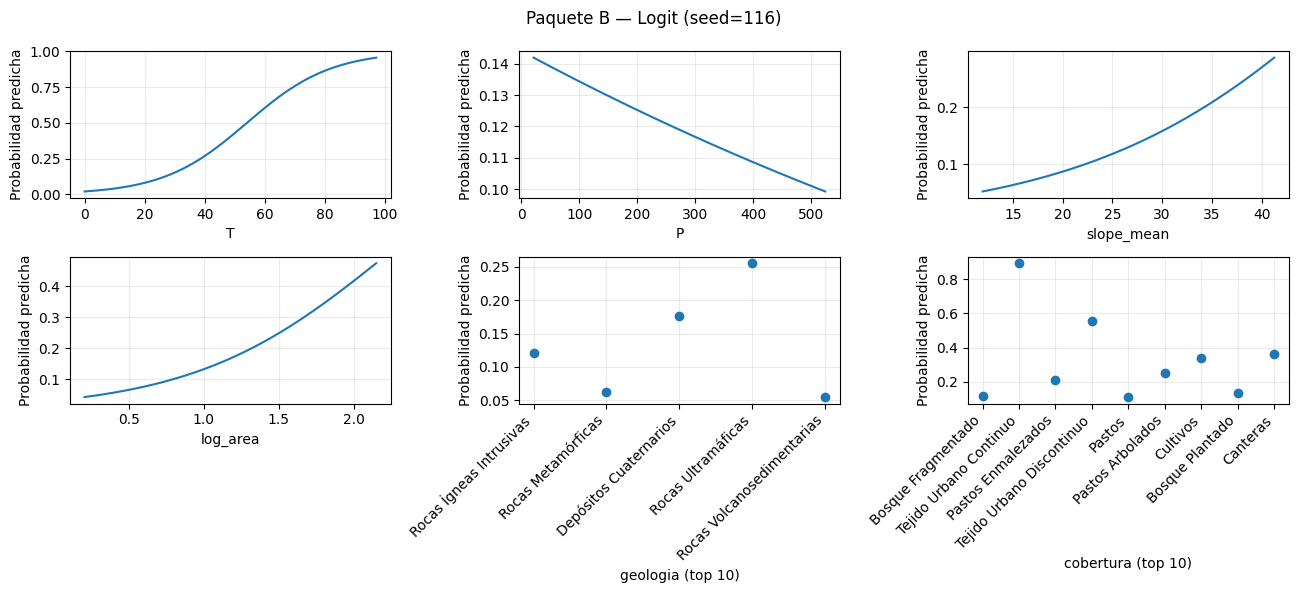

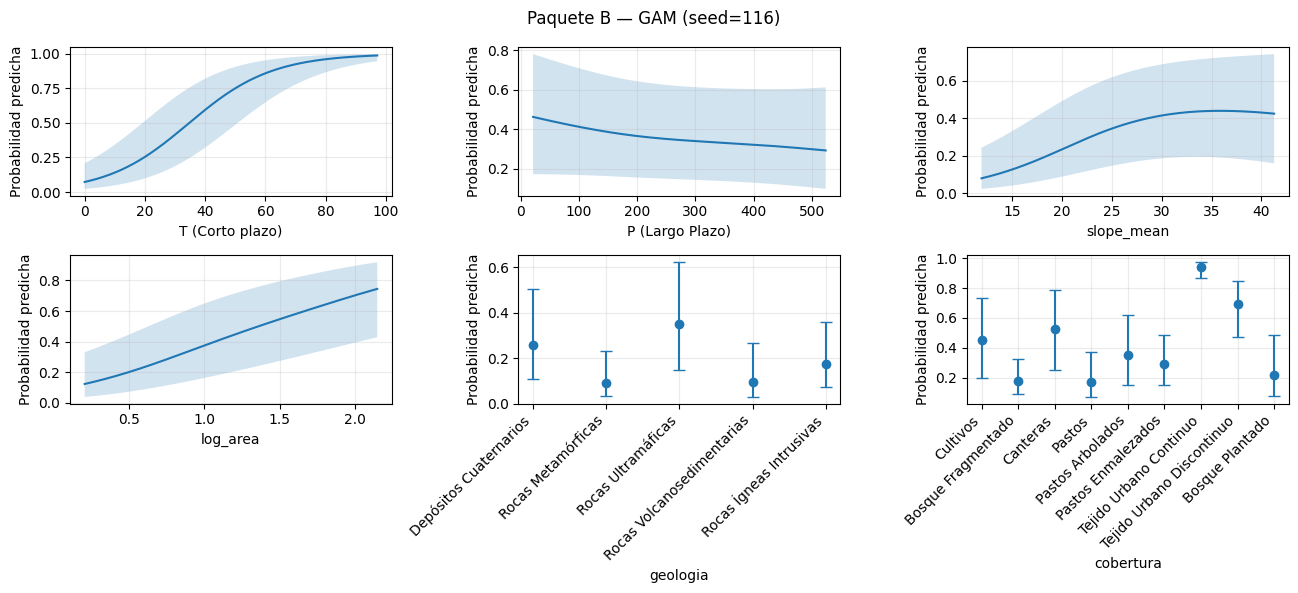

In [64]:
cov_rename = {
    "0":"Cultivos",
    "1":"Bosque Fragmentado",
    "2":"Canteras",
    "3":"Pastos",
    "4":"Cuerpos de agua",
    "5":"Pastos Arbolados",
    "6":"Pastos Enmalezados",
    "7":"Tejido Urbano Continuo",
    "8":"Tejido Urbano Discontinuo",
    "9":"Bosque Plantado",
}

plot_partial_effects_logit_B(logit, Xm_te, title=f"Paquete B — Logit (seed={SEED})", n_grid=200)

plot_partial_effects_gam_B(
    gam, Xg_te,
    geo_map,
    cov_rename,
    title=f"Paquete B — GAM (seed={SEED})",
    n_grid=200,
    width=0.95
)

plt.show()


In [58]:
import inspect
print(inspect.signature(plot_partial_effects_gam_B))

(gam, Xg_test, geo_code_to_name, cov_code_to_name, title='GAM — efectos parciales (B)', n_grid=200, width=0.95)


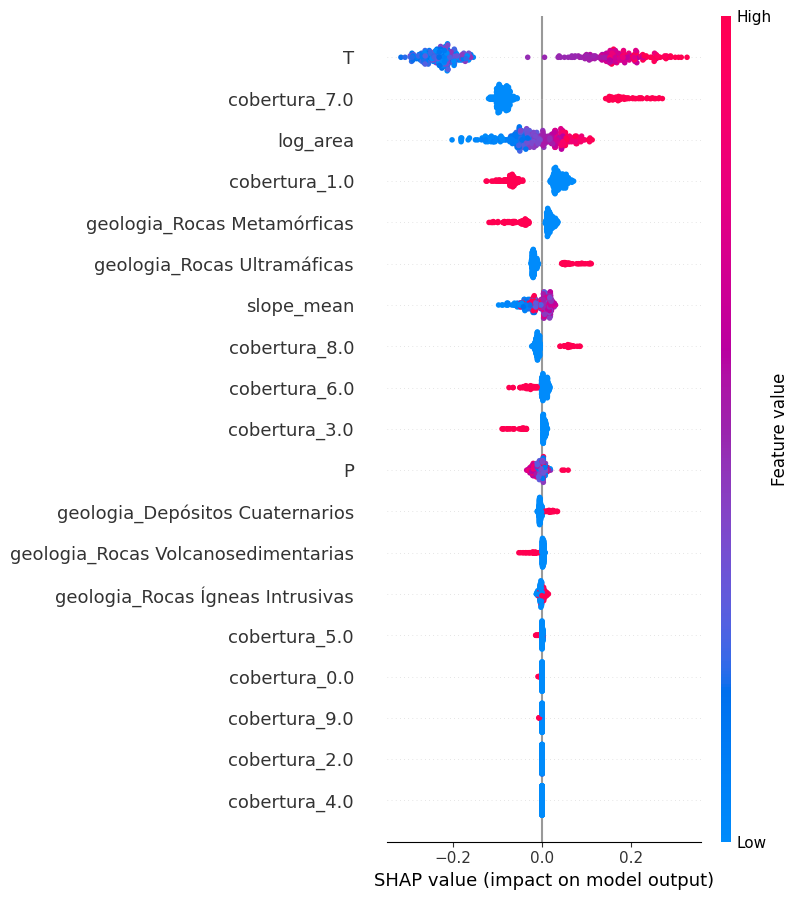

In [65]:
import shap
#============================================================
# 7) SHAP para RF (Pipeline) en espacio original (T,P,slope,log_area,geo,cov)
# ============================================================
def shap_summary_rf_pipeline(rf_pipe, Xm_test, feature_names=["T","P","slope_mean","log_area","geologia","cobertura"]):
    # Transformamos con el preprocesador para explicar el modelo real (post one-hot)
    prep = rf_pipe.named_steps["prep"]
    clf  = rf_pipe.named_steps["clf"]
    X_trans = prep.transform(Xm_test)

    # nombres de features post one-hot
    ohe = prep.named_transformers_["cat"]
    cat_cols = ["geologia", "cobertura"]
    num_cols = ["T", "P", "slope_mean", "log_area"]
    cat_names = ohe.get_feature_names_out(cat_cols)
    feat_out = np.concatenate([np.array(num_cols), cat_names])

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_trans)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(shap_vals, pd.DataFrame(X_trans, columns=feat_out), plot_type="dot", show=True)
    return shap_vals, feat_out

# # SHAP (RF)
shap_vals_B, feat_out_B = shap_summary_rf_pipeline(rf, Xm_te)

In [11]:
# ============================================================
# 5) Plot importancia (igual A)
# ============================================================
def plot_importance_dot_ci(imp_df, model_name, title=None):
    d = imp_df[imp_df["modelo"] == model_name].copy()
    g = d.groupby("variable").agg(
        mean_drop=("auc_drop_mean", "median"),
        lo=("auc_drop_p025", "median"),
        hi=("auc_drop_p975", "median"),
    ).reset_index().sort_values("mean_drop")

    y = np.arange(len(g))
    fig, ax = plt.subplots(figsize=(7, 3.2))
    ax.hlines(y, g["lo"], g["hi"], linewidth=2)
    ax.plot(g["mean_drop"], y, "o", markersize=7)
    ax.set_yticks(y)
    ax.set_yticklabels(g["variable"])
    ax.set_xlabel("Importancia (ΔAUROC tras permutar)")
    ax.set_title(title or f"Permutation importance — {model_name}")
    ax.grid(True, axis="x", alpha=0.25)
    plt.tight_layout()
    return fig, ax


# ============================================================
# 6) Efectos parciales (Logit) + (GAM con CI)
#    Nota: para categorías, se reporta efecto por nivel (manteniendo resto fijo)
# ============================================================
def make_reference_point_df(X_df, strategy="median"):
    ref = {}
    num_cols = ["T", "P", "slope_mean", "log_area"]
    cat_cols = ["geologia", "cobertura"]

    if strategy == "median":
        for c in num_cols:
            ref[c] = float(np.nanmedian(X_df[c].to_numpy(float)))
    else:
        for c in num_cols:
            ref[c] = float(np.nanmean(X_df[c].to_numpy(float)))

    for c in cat_cols:
        ref[c] = X_df[c].mode(dropna=True).iloc[0]

    return ref

def proba1_df(model, X_df):
    p = np.asarray(model.predict_proba(X_df))
    return p[:, 1] if p.ndim == 2 else p

def curve_numeric_df(model, X_df, ref, var, grid):
    Xg = pd.DataFrame({k: [v]*len(grid) for k, v in ref.items()})
    Xg[var] = grid
    # asegura tipos cat
    Xg["geologia"] = Xg["geologia"].astype(str)
    Xg["cobertura"] = Xg["cobertura"].astype(str)
    return proba1_df(model, Xg)

def effect_categorical_df(model, ref, var, levels):
    Xg = pd.DataFrame({k: [v]*len(levels) for k, v in ref.items()})
    Xg[var] = levels
    Xg["geologia"] = Xg["geologia"].astype(str)
    Xg["cobertura"] = Xg["cobertura"].astype(str)
    return np.array(levels), proba1_df(model, Xg)

# ---- GAM CI robusto ----
def gam_proba_and_ci(gam, Xg, width=0.95):
    p = np.asarray(gam.predict_proba(Xg)).ravel()
    if hasattr(gam, "prediction_intervals"):
        ci = gam.prediction_intervals(Xg, width=width)
    elif hasattr(gam, "confidence_intervals"):
        ci = gam.confidence_intervals(Xg, width=width)
    else:
        raise AttributeError("pyGAM sin intervals; hacemos bootstrap si quieres.")
    return p, ci[:, 0], ci[:, 1]

def plot_partial_effects_logit_B(logit, Xm_test, title="Logit — efectos parciales (B)", n_grid=200):
    ref = make_reference_point_df(Xm_test, strategy="median")

    # grids numéricos
    grids = {
        "T": np.linspace(np.percentile(Xm_test["T"], 1), np.percentile(Xm_test["T"], 99), n_grid),
        "P": np.linspace(np.percentile(Xm_test["P"], 1), np.percentile(Xm_test["P"], 99), n_grid),
        "slope_mean": np.linspace(np.percentile(Xm_test["slope_mean"], 1), np.percentile(Xm_test["slope_mean"], 99), n_grid),
        "log_area": np.linspace(np.percentile(Xm_test["log_area"], 1), np.percentile(Xm_test["log_area"], 99), n_grid),
    }

    # niveles categóricos (top N para no hacer una “sopa”)
    top_geo = Xm_test["geologia"].value_counts().head(10).index.astype(str).tolist()
    top_cov = Xm_test["cobertura"].value_counts().head(10).index.astype(str).tolist()

    fig, axs = plt.subplots(2, 3, figsize=(13, 6))

    # numéricas
    for ax, var in zip(axs.ravel()[:4], ["T", "P", "slope_mean", "log_area"]):
        p = curve_numeric_df(logit, Xm_test, ref, var, grids[var])
        ax.plot(grids[var], p)
        ax.set_xlabel(var)
        ax.set_ylabel("Probabilidad predicha")
        ax.grid(True, alpha=0.25)

    # geologia (niveles)
    ax = axs.ravel()[4]
    lev, p = effect_categorical_df(logit, ref, "geologia", top_geo)
    ax.plot(np.arange(len(lev)), p, "o")
    ax.set_xticks(np.arange(len(lev)))
    ax.set_xticklabels(lev, rotation=45, ha="right")
    ax.set_xlabel("geologia (top 10)")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    # cobertura (niveles)
    ax = axs.ravel()[5]
    lev, p = effect_categorical_df(logit, ref, "cobertura", top_cov)
    ax.plot(np.arange(len(lev)), p, "o")
    ax.set_xticks(np.arange(len(lev)))
    ax.set_xticklabels(lev, rotation=45, ha="right")
    ax.set_xlabel("cobertura (top 10)")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs

def plot_partial_effects_gam_B(gam, Xg_test, title="GAM — efectos parciales (B)", n_grid=200, width=0.95):
    x_ref = np.median(Xg_test, axis=0)

    # grids numéricos
    grids = {
        0: np.linspace(np.percentile(Xg_test[:, 0], 1), np.percentile(Xg_test[:, 0], 99), n_grid),  # T
        1: np.linspace(np.percentile(Xg_test[:, 1], 1), np.percentile(Xg_test[:, 1], 99), n_grid),  # P
        2: np.linspace(np.percentile(Xg_test[:, 2], 1), np.percentile(Xg_test[:, 2], 99), n_grid),  # slope
        3: np.linspace(np.percentile(Xg_test[:, 3], 1), np.percentile(Xg_test[:, 3], 99), n_grid),  # log_area
    }

    fig, axs = plt.subplots(2, 3, figsize=(13, 6))

    # numéricas con CI
    labels = {0:"T", 1:"P", 2:"slope_mean", 3:"log_area"}
    for ax, j in zip(axs.ravel()[:4], [0, 1, 2, 3]):
        Xtmp = np.tile(x_ref, (len(grids[j]), 1))
        Xtmp[:, j] = grids[j]
        p, lo, hi = gam_proba_and_ci(gam, Xtmp, width=width)
        ax.plot(grids[j], p)
        ax.fill_between(grids[j], lo, hi, alpha=0.2)
        ax.set_xlabel(labels[j])
        ax.set_ylabel("Probabilidad predicha")
        ax.grid(True, alpha=0.25)

    # factores: geologia/cobertura (por código)
    ax = axs.ravel()[4]
    geo_codes = np.unique(Xg_test[:, 4].astype(int))
    Xtmp = np.tile(x_ref, (len(geo_codes), 1))
    Xtmp[:, 4] = geo_codes
    p, lo, hi = gam_proba_and_ci(gam, Xtmp, width=width)
    yerr = np.vstack([p - lo, hi - p])
    ax.errorbar(geo_codes, p, yerr=yerr, fmt="o", capsize=4, linestyle="none")
    ax.set_xlabel("geologia_code")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    ax = axs.ravel()[5]
    cov_codes = np.unique(Xg_test[:, 5].astype(int))
    Xtmp = np.tile(x_ref, (len(cov_codes), 1))
    Xtmp[:, 5] = cov_codes
    p, lo, hi = gam_proba_and_ci(gam, Xtmp, width=width)
    yerr = np.vstack([p - lo, hi - p])
    ax.errorbar(cov_codes, p, yerr=yerr, fmt="o", capsize=4, linestyle="none")
    ax.set_xlabel("cobertura_code")
    ax.set_ylabel("Probabilidad predicha")
    ax.grid(True, alpha=0.25)

    fig.suptitle(title)
    plt.tight_layout()
    return fig, axs

# ============================================================
# 7) SHAP para RF (Pipeline) en espacio original (T,P,slope,log_area,geo,cov)
# ============================================================
def shap_summary_rf_pipeline(rf_pipe, Xm_test, feature_names=["T","P","slope_mean","log_area","geologia","cobertura"]):
    # Transformamos con el preprocesador para explicar el modelo real (post one-hot)
    prep = rf_pipe.named_steps["prep"]
    clf  = rf_pipe.named_steps["clf"]
    X_trans = prep.transform(Xm_test)

    # nombres de features post one-hot
    ohe = prep.named_transformers_["cat"]
    cat_cols = ["geologia", "cobertura"]
    num_cols = ["T", "P", "slope_mean", "log_area"]
    cat_names = ohe.get_feature_names_out(cat_cols)
    feat_out = np.concatenate([np.array(num_cols), cat_names])

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_trans)
    shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

    shap.summary_plot(shap_vals, pd.DataFrame(X_trans, columns=feat_out), plot_type="dot", show=True)
    return shap_vals, feat_out


In [ ]:
import json
import pandas as pd

# 1) cargar selección
json_path = "/home/oisanchezp/Thesis/data/processed/seleccion_corrida_mediana_paquete_b.json"
with open(json_path, "r") as f:
    selB = json.load(f)

# 2) reconstruir df_mc_B usando TU constructor del paquete B
df_star_B = construir_si_no_spatial_mc(
    seed=selB["seed_star"],
    path_gpkg=path_gpkg,
    layer_in=layer_in,
    pluv_meta_csv=pluv_meta,
    ruta_series=ruta_series,
    min_dist_m=MIN_DIST_M
)


In [ ]:
# ============================================================
# 8) USO (ejemplo)
# ============================================================
df_star_B = '/home/oisanchezp/Thesis/data/processed/seleccion_corrida_mediana_paquete_b.json'

resultados_B, imp_df_B, models_B, test_B = evaluate_models_once_B(df_star_B, thr=0.5)
(gam_B, logit_B, rf_B) = models_B
((Xg_te, Xm_te), y_te) = test_B

# Efectos parciales
plot_partial_effects_logit_B(logit_B, Xm_te, title="Paquete B — Logit — efectos parciales")
plot_partial_effects_gam_B(gam_B, Xg_te, title="Paquete B — GAM — efectos parciales", width=0.95)
plt.show()



AttributeError: 'str' object has no attribute 'dropna'

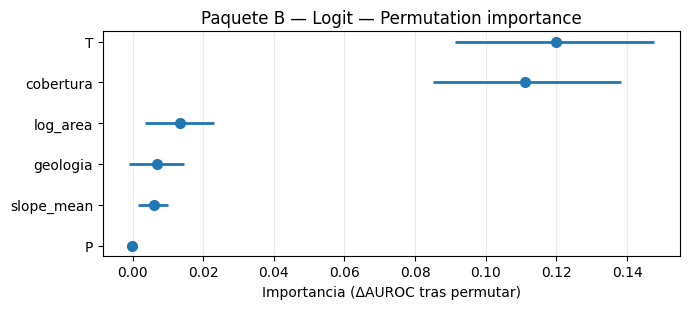

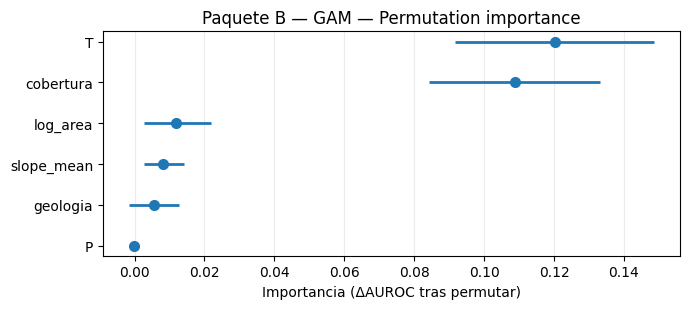

In [ ]:


# Importancia (perm)
imp_df_B = pd.read_csv("/home/oisanchezp/Thesis/data/processed/importancia2026_b_Logit_GAM.csv")
plot_importance_dot_ci(imp_df_B, "Logit", "Paquete B — Logit — Permutation importance")
plot_importance_dot_ci(imp_df_B, "GAM",   "Paquete B — GAM — Permutation importance")
plt.show()

